# Integración del análisis de potencia del mecanismo de cuatro barras

En este cuaderno el análisis de potencia se construye como la continuación natural del análisis de **posiciones, velocidades y aceleraciones**.

Además de la gravedad y de los términos de inercia, se incorpora una fuerza externa aplicada en un punto \(P\) del eslabón 3. La potencia asociada a esta fuerza se calcula mediante

\[
P_F = \vec{F}\cdot\vec{v}_P
\]

y se incluye directamente en el balance total de potencia del mecanismo.


## 1. Variables y ecuaciones base


In [1]:

import sympy as sp
import numpy as np
from scipy.optimize import fsolve

# Variable independiente
t = sp.symbols('t', real=True)

# Parámetros geométricos
L1, L2, L3, L4 = sp.symbols('L1 L2 L3 L4', real=True, positive=True)

# Coordenadas angulares dependientes del tiempo
theta_2 = sp.Function('theta_2')(t)
theta_3 = sp.Function('theta_3')(t)
theta_4 = sp.Function('theta_4')(t)

# Velocidades y aceleraciones angulares para reemplazo
omega_2, omega_3, omega_4 = sp.symbols('omega_2 omega_3 omega_4', real=True)
alpha_2, alpha_3, alpha_4 = sp.symbols('alpha_2 alpha_3 alpha_4', real=True)

subs_dict = {
    sp.diff(theta_2, t): omega_2,
    sp.diff(theta_3, t): omega_3,
    sp.diff(theta_4, t): omega_4,
    sp.diff(theta_2, (t, 2)): alpha_2,
    sp.diff(theta_3, (t, 2)): alpha_3,
    sp.diff(theta_4, (t, 2)): alpha_4,
}

# Ecuaciones de posición del lazo
F = sp.Matrix([
    L2*sp.cos(theta_2) + L3*sp.cos(theta_3) - L4*sp.cos(theta_4) - L1,
    L2*sp.sin(theta_2) + L3*sp.sin(theta_3) - L4*sp.sin(theta_4)
])

display(F)


Matrix([
[-L1 + L2*cos(theta_2(t)) + L3*cos(theta_3(t)) - L4*cos(theta_4(t))],
[      L2*sin(theta_2(t)) + L3*sin(theta_3(t)) - L4*sin(theta_4(t))]])

## 2. Velocidades y aceleraciones

Aquí se reutiliza exactamente la misma idea: derivar el lazo y resolver el sistema lineal usando el jacobiano.

In [2]:

Vel_equation = sp.diff(F, t)
Acel_equation = sp.diff(F, t, 2)

Vel = Vel_equation.subs(subs_dict)
Acel = Acel_equation.subs(subs_dict)

A_vel, B_vel = sp.linear_eq_to_matrix(Vel, [omega_3, omega_4])
A_acel, B_acel = sp.linear_eq_to_matrix(Acel, [alpha_3, alpha_4])

display(A_vel)
display(B_vel)
display(B_acel)


Matrix([
[-L3*sin(theta_3(t)),  L4*sin(theta_4(t))],
[ L3*cos(theta_3(t)), -L4*cos(theta_4(t))]])

Matrix([
[ L2*omega_2*sin(theta_2(t))],
[-L2*omega_2*cos(theta_2(t))]])

Matrix([
[ L2*alpha_2*sin(theta_2(t)) + L2*omega_2**2*cos(theta_2(t)) + L3*omega_3**2*cos(theta_3(t)) - L4*omega_4**2*cos(theta_4(t))],
[-L2*alpha_2*cos(theta_2(t)) + L2*omega_2**2*sin(theta_2(t)) + L3*omega_3**2*sin(theta_3(t)) - L4*omega_4**2*sin(theta_4(t))]])

In [3]:

def get_ordered_variables(expr, indep_var=None):
    """
    Devuelve una lista ordenada con:
    1) símbolos libres
    2) funciones de la variable independiente
    """
    syms = expr.free_symbols
    if indep_var is not None and indep_var in syms:
        syms = syms - {indep_var}
    syms = sorted(syms, key=lambda s: str(s))

    funcs = {f for f in expr.atoms(sp.Function) if not isinstance(f, (sp.sin, sp.cos))}
    funcs = sorted(funcs, key=lambda f: str(f))
    return syms + funcs

# Funciones lambda ya conocidas del análisis cinemático
variables_F = get_ordered_variables(F)
variables_B_vel = get_ordered_variables(B_vel)
variables_B_acel = get_ordered_variables(B_acel)

J = F.jacobian([theta_3, theta_4])
variables_J = get_ordered_variables(J)

F_fun = sp.lambdify(variables_F, F, 'numpy')
J_fun = sp.lambdify(variables_J, J, 'numpy')
B_vel_fun = sp.lambdify(variables_B_vel, B_vel, 'numpy')
B_acel_fun = sp.lambdify(variables_B_acel, B_acel, 'numpy')


## 3. Solución numérica de posición, velocidad y aceleración

Se mantiene el mismo flujo numérico del cuaderno anterior. La diferencia es que estos resultados ahora serán la entrada directa del análisis de potencia.

In [4]:

def fourbar_eqs(x, L1_val, L2_val, L3_val, L4_val, theta2_val):
    theta3_val, theta4_val = x
    F1 = L2_val*np.cos(theta2_val) + L3_val*np.cos(theta3_val) - L4_val*np.cos(theta4_val) - L1_val
    F2 = L2_val*np.sin(theta2_val) + L3_val*np.sin(theta3_val) - L4_val*np.sin(theta4_val)
    return [F1, F2]

# Parámetros geométricos de ejemplo
L1_val = 0.1 #m
L2_val = 0.020 #m
L3_val = 0.080 #m
L4_val = 0.060 #m

# Estado de entrada
theta2_deg = 110.0
theta2_val = np.deg2rad(theta2_deg)
omega2_val = 10.0 * 2*np.pi / 60.0   # 10 rpm
alpha2_val = 0.0

# Solución de posición
x0 = np.deg2rad([30.0, 90.0])
sol, info, ier, msg = fsolve(
    fourbar_eqs,
    x0,
    args=(L1_val, L2_val, L3_val, L4_val, theta2_val),
    full_output=True
)

if ier != 1:
    raise RuntimeError(f"No convergió: {msg}")

theta3_val, theta4_val = sol

# Solución de velocidad
J0 = np.array(J_fun(L3_val, L4_val, t, theta3_val, theta4_val), dtype=float)
B_vel_0 = np.array(B_vel_fun(L2_val, omega2_val, t, theta2_val), dtype=float)
vel_sol = np.linalg.solve(J0, B_vel_0)
omega3_val = float(vel_sol[0, 0])
omega4_val = float(vel_sol[1, 0])

# Solución de aceleración
B_acel_0 = np.array(
    B_acel_fun(L2_val, L3_val, L4_val,
               alpha2_val, omega2_val, omega3_val, omega4_val,
               t, theta2_val, theta3_val, theta4_val),
    dtype=float
)
acc_sol = np.linalg.solve(J0, B_acel_0)
alpha3_val = float(acc_sol[0, 0])
alpha4_val = float(acc_sol[1, 0])

print(f"theta_3 = {np.rad2deg(theta3_val):.4f} deg")
print(f"theta_4 = {np.rad2deg(theta4_val):.4f} deg")
print(f"omega_3 = {omega3_val:.6f} rad/s")
print(f"omega_4 = {omega4_val:.6f} rad/s")
print(f"alpha_3 = {alpha3_val:.6f} rad/s^2")
print(f"alpha_4 = {alpha4_val:.6f} rad/s^2")


theta_3 = 22.9546 deg
theta_4 = 123.5677 deg
omega_3 = -0.062485 rad/s
omega_4 = 0.354669 rad/s
alpha_3 = 0.174427 rad/s^2
alpha_4 = 0.048037 rad/s^2


## 4. El análisis de potencia como paso siguiente

Una vez conocidas las posiciones, velocidades y aceleraciones, ya es posible calcular potencia.

La idea general es:

$$P =
\sum F\cdot
v + 	\sum \tau\cdot\omega$$

Por tanto, el siguiente paso natural consiste en obtener las velocidades de los puntos donde actúan fuerzas y las velocidades angulares de los eslabones donde actúan pares.

### 4.1 Vectores de posición de centros de masa

Para mantener consistencia con la formulación anterior, se definen las posiciones del centro de gravedad de cada eslabón y luego se derivan para obtener velocidad y aceleración.

In [5]:

# Distancias a los centros de masa medidas desde la articulación proximal de cada eslabón
lg2, lg3, lg4 = sp.symbols('lg2 lg3 lg4', real=True, positive=True)

# Masas y momentos de inercia
m2, m3, m4 = sp.symbols('m2 m3 m4', real=True, positive=True)
I2, I3, I4 = sp.symbols('I2 I3 I4', real=True, positive=True)

# Gravedad
g = sp.symbols('g', real=True, positive=True)

# Posiciones de centros de masa
L_g2 = sp.Matrix([
    lg2*sp.cos(theta_2),
    lg2*sp.sin(theta_2)
])

L_2 = sp.Matrix([
    L2*sp.cos(theta_2),
    L2*sp.sin(theta_2)
])

L_g3 = L_2 + sp.Matrix([
    lg3*sp.cos(theta_3),
    lg3*sp.sin(theta_3)
])

L_g4 = sp.Matrix([
    L1, 0
]) + sp.Matrix([
    lg4*sp.cos(theta_4),
    lg4*sp.sin(theta_4)
])

# Velocidades y aceleraciones de los centros de masa
v_g2 = sp.diff(L_g2, t).subs(subs_dict)
v_g3 = sp.diff(L_g3, t).subs(subs_dict)
v_g4 = sp.diff(L_g4, t).subs(subs_dict)

a_g2 = sp.diff(L_g2, t, 2).subs(subs_dict)
a_g3 = sp.diff(L_g3, t, 2).subs(subs_dict)
a_g4 = sp.diff(L_g4, t, 2).subs(subs_dict)

display(v_g2)
display(v_g3)
display(v_g4)

display(a_g2)
display(a_g3)
display(a_g4)


Matrix([
[-lg2*omega_2*sin(theta_2(t))],
[ lg2*omega_2*cos(theta_2(t))]])

Matrix([
[-L2*omega_2*sin(theta_2(t)) - lg3*omega_3*sin(theta_3(t))],
[ L2*omega_2*cos(theta_2(t)) + lg3*omega_3*cos(theta_3(t))]])

Matrix([
[-lg4*omega_4*sin(theta_4(t))],
[ lg4*omega_4*cos(theta_4(t))]])

Matrix([
[-lg2*(alpha_2*sin(theta_2(t)) + omega_2**2*cos(theta_2(t)))],
[ lg2*(alpha_2*cos(theta_2(t)) - omega_2**2*sin(theta_2(t)))]])

Matrix([
[-L2*alpha_2*sin(theta_2(t)) - L2*omega_2**2*cos(theta_2(t)) - alpha_3*lg3*sin(theta_3(t)) - lg3*omega_3**2*cos(theta_3(t))],
[ L2*alpha_2*cos(theta_2(t)) - L2*omega_2**2*sin(theta_2(t)) + alpha_3*lg3*cos(theta_3(t)) - lg3*omega_3**2*sin(theta_3(t))]])

Matrix([
[-lg4*(alpha_4*sin(theta_4(t)) + omega_4**2*cos(theta_4(t)))],
[ lg4*(alpha_4*cos(theta_4(t)) - omega_4**2*sin(theta_4(t)))]])

### 4.2 Punto de aplicación de la fuerza externa

El punto \(P\) se encuentra fijo al eslabón 3. Su posición se define a partir de la articulación entre los eslabones 2 y 3.

Se considera una distancia \(L'_3\) desde esta articulación hasta \(P\), formando un ángulo constante \(lpha\) con el eslabón 3.

La potencia de la fuerza externa se obtiene a partir de la velocidad del punto \(P\).


In [ ]:
# Geometría del punto P
L3p, alpha = sp.symbols('L3p alpha', real=True)

# Componentes de la fuerza externa
Fx, Fy = sp.symbols('Fx Fy', real=True)

# Posición del punto P
r_P = L_2 + sp.Matrix([
    L3p*sp.cos(theta_3 + alpha),
    L3p*sp.sin(theta_3 + alpha)
])

# Velocidad del punto P
v_P = sp.diff(r_P, t).subs(subs_dict)

# Fuerza externa y potencia asociada
F_ext = sp.Matrix([
    Fx,
    Fy
])

P_F = sp.simplify(F_ext.dot(v_P))

print('Posición del punto P:')
display(r_P)

print('Velocidad del punto P:')
display(v_P)

print('Potencia de la fuerza externa:')
display(P_F)


### 4.3 Potencias de gravedad, inercia traslacional e inercia rotacional

Para el mecanismo completo es conveniente sumar contribuciones por eslabón.

- Potencia de gravedad: $P_g =
\sum W_i\cdot
v$
- Potencia inercial traslacional: $P_{ma} = \sum (-m
a_{gi})\cdot
v_{gi}$
- Potencia inercial rotacional: $P_{I\alpha} = \sum (-I\alpha)\omega$

Las reacciones en apoyos fijos no aportan potencia porque su punto de aplicación tiene velocidad nula. Las fuerzas internas entre eslabones se cancelan al considerar el mecanismo completo.

In [6]:

# Fuerzas peso
W2 = sp.Matrix([0, -m2*g])
W3 = sp.Matrix([0, -m3*g])
W4 = sp.Matrix([0, -m4*g])

# Potencias debidas a la gravedad
P_g2 = sp.simplify(W2.dot(v_g2))
P_g3 = sp.simplify(W3.dot(v_g3))
P_g4 = sp.simplify(W4.dot(v_g4))

# Potencias debidas a la inercia traslacional
P_ma2 = sp.simplify((-m2*a_g2).dot(v_g2))
P_ma3 = sp.simplify((-m3*a_g3).dot(v_g3))
P_ma4 = sp.simplify((-m4*a_g4).dot(v_g4))

# Potencias debidas a la inercia rotacional
P_Ia2 = sp.simplify((-I2*alpha_2)*omega_2)
P_Ia3 = sp.simplify((-I3*alpha_3)*omega_3)
P_Ia4 = sp.simplify((-I4*alpha_4)*omega_4)

# Par de entrada
tau_in = sp.symbols('tau_in', real=True)
P_in = sp.simplify(tau_in*omega_2)

print('Potencia de entrada: ')
display(P_in)
print('Potencia debido a la gravedad: ')
display(P_g2)
display(P_g3)
display(P_g4)
print('Potencia debido a la inercia traslacional: ')
display(P_ma2)
display(P_ma3)
display(P_ma4)
print('Potencia debido a la inercia rotacional: ')
display(P_Ia2)
display(P_Ia3)
display(P_Ia4)


Potencia de entrada: 


omega_2*tau_in

Potencia debido a la gravedad: 


-g*lg2*m2*omega_2*cos(theta_2(t))

-g*m3*(L2*omega_2*cos(theta_2(t)) + lg3*omega_3*cos(theta_3(t)))

...

-alpha_4*lg4**2*m4*omega_4

Potencia debido a la inercia rotacional: 


-I2*alpha_2*omega_2

-I3*alpha_3*omega_3

-I4*alpha_4*omega_4

### 4.4 Balance total de potencia

La suma algebraica de potencias se puede escribir como

\[
P_{in} + P_F + \sum P_g + \sum P_{ma} + \sum P_{I\alpha} = 0
\]

donde \(P_F=\vec{F}\cdot\vec{v}_P\) es la potencia asociada a la fuerza externa.

El signo de \(P_F\) aparece naturalmente a partir del producto punto. Si la fuerza se opone al movimiento de \(P\), su potencia será negativa; si favorece el movimiento, será positiva.

De esta ecuación puede despejarse el par de entrada requerido \(\tau_{in}\).


In [7]:
P_total = sp.simplify(
    P_in
    + P_F
    + P_g2 + P_g3 + P_g4
    + P_ma2 + P_ma3 + P_ma4
    + P_Ia2 + P_Ia3 + P_Ia4
)

# Despeje del par de entrada a partir del balance instantáneo de potencia
sol_tau_in = sp.solve(sp.Eq(P_total, 0), tau_in)
tau_in_expr = sp.simplify(sol_tau_in[0])

display(sp.Eq(tau_in, tau_in_expr))


Eq(tau_in, (I3*alpha_3*omega_3 + I4*alpha_4*omega_4 + L2*alpha_2*lg3*m3*omega_3*cos(theta_2(t) - theta_3(t)) + alpha_3*lg3**2*m3*omega_3 + alpha_4*lg4**2*m4*omega_4 + g*lg3*m3*omega_3*cos(theta_3(t)) + g*lg4*m4*omega_4*cos(theta_4(t)) + omega_2*(I2*alpha_2 + L2**2*alpha_2*m3 + L2*alpha_3*lg3*m3*cos(theta_2(t) - theta_3(t)) + L2*g*m3*cos(theta_2(t)) - L2*lg3*m3*omega_2*omega_3*sin(theta_2(t) - theta_3(t)) + L2*lg3*m3*omega_3**2*sin(theta_2(t) - theta_3(t)) + alpha_2*lg2**2*m2 + g*lg2*m2*cos(theta_2(t))))/omega_2)

## 5. Funciones lambda para el análisis de potencia

Aquí se sigue la misma filosofía del cuaderno anterior: convertir expresiones simbólicas en funciones numéricas reutilizables.

In [8]:
# Funciones lambda de potencia
P_F_fun = sp.lambdify(get_ordered_variables(P_F), P_F, 'numpy')

P_g2_fun = sp.lambdify(get_ordered_variables(P_g2), P_g2, 'numpy')
P_g3_fun = sp.lambdify(get_ordered_variables(P_g3), P_g3, 'numpy')
P_g4_fun = sp.lambdify(get_ordered_variables(P_g4), P_g4, 'numpy')

P_ma2_fun = sp.lambdify(get_ordered_variables(P_ma2), P_ma2, 'numpy')
P_ma3_fun = sp.lambdify(get_ordered_variables(P_ma3), P_ma3, 'numpy')
P_ma4_fun = sp.lambdify(get_ordered_variables(P_ma4), P_ma4, 'numpy')

P_Ia2_fun = sp.lambdify(get_ordered_variables(P_Ia2), P_Ia2, 'numpy')
P_Ia3_fun = sp.lambdify(get_ordered_variables(P_Ia3), P_Ia3, 'numpy')
P_Ia4_fun = sp.lambdify(get_ordered_variables(P_Ia4), P_Ia4, 'numpy')

tau_in_fun = sp.lambdify(get_ordered_variables(tau_in_expr), tau_in_expr, 'numpy')

print('Variables potencia de la fuerza externa')
print(get_ordered_variables(P_F))

print('Variables potencia gravedad')
print(get_ordered_variables(P_g2))
print(get_ordered_variables(P_g3))
print(get_ordered_variables(P_g4))

print('Variables potencia inercia lineal')
print(get_ordered_variables(P_ma2))
print(get_ordered_variables(P_ma3))
print(get_ordered_variables(P_ma4))

print('Variables potencia inercia rotacional')
print(get_ordered_variables(P_Ia2))
print(get_ordered_variables(P_Ia3))
print(get_ordered_variables(P_Ia4))

print('Variables torque')
print(get_ordered_variables(tau_in_expr))


Variables potencia gravedad
[g, lg2, m2, omega_2, t, theta_2(t)]
[L2, g, lg3, m3, omega_2, omega_3, t, theta_2(t), theta_3(t)]
[g, lg4, m4, omega_4, t, theta_4(t)]
Variables potencia inercia lineal
[alpha_2, lg2, m2, omega_2]
[L2, alpha_2, alpha_3, lg3, m3, omega_2, omega_3, t, theta_2(t), theta_3(t)]
[alpha_4, lg4, m4, omega_4]
Variables potencia inercia rotaional
[I2, alpha_2, omega_2]
[I3, alpha_3, omega_3]
[I4, alpha_4, omega_4]
Variables torque
[I2, I3, I4, L2, alpha_2, alpha_3, alpha_4, g, lg2, lg3, lg4, m2, m3, m4, omega_2, omega_3, omega_4, t, theta_2(t), theta_3(t), theta_4(t)]


## 6. Evaluación numérica

En esta parte se usan directamente los resultados cinemáticos obtenidos arriba. Así queda explícito que el análisis de potencia depende de la solución previa de posición, velocidad y aceleración.

In [9]:
# Parámetros dinámicos de ejemplo
lg2_val = L2_val/2
lg3_val = L3_val/2
lg4_val = L4_val/2

m2_val = 0.50   # kg
m3_val = 1.20   # kg
m4_val = 0.80   # kg

I2_val = 2.0e-4   # kg·m^2
I3_val = 1.2e-3   # kg·m^2
I4_val = 6.0e-4   # kg·m^2

g_val = 9.81

# ---------------------------------------------------------
# Fuerza externa aplicada en P
# ---------------------------------------------------------
# Para este ejemplo se utiliza la misma longitud L3 como L3'
# y un ángulo constante alpha = 45°.
L3p_val = L3_val
alpha_val = np.deg2rad(45.0)

# Fuerza de 1000 N en la dirección negativa del eje x
Fx_val = -1000.0   # N
Fy_val = 0.0       # N

F_ext_val = np.array([
    Fx_val,
    Fy_val
], dtype=float)

# Velocidad del punto P
vP_val = np.array([
    -L2_val*np.sin(theta2_val)*omega2_val
    -L3p_val*np.sin(theta3_val + alpha_val)*omega3_val,

     L2_val*np.cos(theta2_val)*omega2_val
    +L3p_val*np.cos(theta3_val + alpha_val)*omega3_val
], dtype=float)

# Potencia asociada a la fuerza externa
PF_val = float(np.dot(F_ext_val, vP_val))

# Potencias individuales
Pg2_val = float(P_g2_fun(g_val, lg2_val, m2_val, omega2_val, t, theta2_val))
Pg3_val = float(P_g3_fun(
    L2_val, g_val, lg3_val, m3_val,
    omega2_val, omega3_val, t, theta2_val, theta3_val
))
Pg4_val = float(P_g4_fun(
    g_val, lg4_val, m4_val, omega4_val, t, theta4_val
))

Pma2_val = float(P_ma2_fun(
    alpha2_val, lg2_val, m2_val, omega2_val
))
Pma3_val = float(P_ma3_fun(
    L2_val, alpha2_val, alpha3_val,
    lg3_val, m3_val,
    omega2_val, omega3_val,
    t, theta2_val, theta3_val
))
Pma4_val = float(P_ma4_fun(
    alpha4_val, lg4_val, m4_val, omega4_val
))

PIa2_val = float(P_Ia2_fun(I2_val, alpha2_val, omega2_val))
PIa3_val = float(P_Ia3_fun(I3_val, alpha3_val, omega3_val))
PIa4_val = float(P_Ia4_fun(I4_val, alpha4_val, omega4_val))

# ---------------------------------------------------------
# Potencia completa requerida por el motor
# ---------------------------------------------------------
# Balance:
# P_in + P_F + sum(P_g) + sum(P_ma) + sum(P_Ia) = 0

P_in_val = -(
    PF_val
    + Pg2_val + Pg3_val + Pg4_val
    + Pma2_val + Pma3_val + Pma4_val
    + PIa2_val + PIa3_val + PIa4_val
)

tau_in_val = P_in_val / omega2_val

P_total_val = (
    P_in_val
    + PF_val
    + Pg2_val + Pg3_val + Pg4_val
    + Pma2_val + Pma3_val + Pma4_val
    + PIa2_val + PIa3_val + PIa4_val
)

print(f"Velocidad de P = [{vP_val[0]:.6f}, {vP_val[1]:.6f}] m/s")
print(f"P_F = {PF_val:.6f} W")
print(f"tau_in = {tau_in_val:.6f} N·m")
print(f"P_in = {P_in_val:.6f} W")
print(f"P_total = {P_total_val:.6e} W")


tau_in = -0.167199 N·m
P_in = -0.175090 W
P_total = -6.493355e-18 W


In [10]:
print('Resumen de potencias instantáneas [W]')
print('-'*45)
print(f"P_in   = {P_in_val: .6f}")
print(f"P_F    = {PF_val: .6f}")
print(f"P_g2   = {Pg2_val: .6f}")
print(f"P_g3   = {Pg3_val: .6f}")
print(f"P_g4   = {Pg4_val: .6f}")
print(f"P_ma2  = {Pma2_val: .6f}")
print(f"P_ma3  = {Pma3_val: .6f}")
print(f"P_ma4  = {Pma4_val: .6f}")
print(f"P_Ia2  = {PIa2_val: .6f}")
print(f"P_Ia3  = {PIa3_val: .6f}")
print(f"P_Ia4  = {PIa4_val: .6f}")
print('-'*45)
print(f"Suma   = {P_total_val: .6e}")


Resumen de potencias instantáneas [W]
---------------------------------------------
P_in   = -0.175090
P_g2   =  0.017568
P_g3   =  0.111419
P_g4   =  0.046171
P_ma2  = -0.000000
P_ma3  = -0.000058
P_ma4  = -0.000012
P_Ia2  = -0.000000
P_Ia3  =  0.000013
P_Ia4  = -0.000010
---------------------------------------------
Suma   = -6.493355e-18


## 7. Comentario final

La secuencia completa queda entonces así:

1. **Posición**: encontrar \(\theta_3\) y \(\theta_4\).
2. **Velocidad**: encontrar \(\omega_3\) y \(\omega_4\).
3. **Aceleración**: encontrar \(\alpha_3\) y \(\alpha_4\).
4. **Velocidad del punto \(P\)**: calcular \(\vec{v}_P\).
5. **Potencia de la fuerza externa**: calcular \(P_F=\vec{F}\cdot\vec{v}_P\).
6. **Potencia completa**: incluir fuerza externa, gravedad, inercia traslacional e inercia rotacional en el balance de potencia.


## 8. Barrido angular completo y gráfica del torque de entrada

En la celda siguiente se extiende el cálculo para recorrer el ángulo del eslabón de entrada desde **0° hasta 360°** con incrementos de **1°**.  
Para cada posición se resuelven:

- la **posición** del mecanismo,
- la **velocidad angular** de los eslabones móviles,
- la **aceleración angular**,
- y el **torque de entrada**.

Finalmente, se genera la gráfica de \(	au_{in}\) en función de \(	heta_2\).


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# =========================================
# BARRIDO DE theta2 DESDE 0° HASTA 360°
# =========================================

def fourbar_eqs(x, L1_val, L2_val, L3_val, L4_val, theta2_val):
    theta3_val, theta4_val = x

    F1 = (
        L2_val*np.cos(theta2_val)
        + L3_val*np.cos(theta3_val)
        - L4_val*np.cos(theta4_val)
        - L1_val
    )

    F2 = (
        L2_val*np.sin(theta2_val)
        + L3_val*np.sin(theta3_val)
        - L4_val*np.sin(theta4_val)
    )

    return [F1, F2]


# =========================
# PARÁMETROS DEL MECANISMO
# =========================

L1_val = 0.100   # m
L2_val = 0.020   # m
L3_val = 0.080   # m
L4_val = 0.060   # m

omega2_val = 10.0 * 2*np.pi / 60.0   # 10 rpm -> rad/s
alpha2_val = 0.0

lg2_val = L2_val / 2
lg3_val = L3_val / 2
lg4_val = L4_val / 2

m2_val = 0.50   # kg
m3_val = 1.20   # kg
m4_val = 0.80   # kg

I2_val = 2.0e-4   # kg·m^2
I3_val = 1.2e-3   # kg·m^2
I4_val = 6.0e-4   # kg·m^2

g_val = 9.81

# =========================
# FUERZA EXTERNA EN P
# =========================

L3p_val = L3_val
alpha_val = np.deg2rad(45.0)

Fx_val = -1000.0   # N
Fy_val = 0.0       # N

F_ext_val = np.array([
    Fx_val,
    Fy_val
], dtype=float)


# ============================================================
# LISTAS PARA GUARDAR LOS RESULTADOS DE CADA ITERACIÓN
# ============================================================

theta2_deg_list = []
theta2_rad_list = []

theta3_deg_list = []
theta4_deg_list = []

omega3_list = []
omega4_list = []

alpha3_list = []
alpha4_list = []

xP_list = []
yP_list = []

vPx_list = []
vPy_list = []

PF_list = []

Pg2_list = []
Pg3_list = []
Pg4_list = []

Pma2_list = []
Pma3_list = []
Pma4_list = []

PIa2_list = []
PIa3_list = []
PIa4_list = []

P_in_list = []
tau_in_list = []
P_total_list = []


# Semilla inicial para fsolve
x_guess = np.deg2rad([30.0, 90.0])


# =========================
# BARRIDO ANGULAR
# =========================

for theta2_deg in range(0, 361, 1):

    theta2_val = np.deg2rad(theta2_deg)

    # Guardamos siempre la entrada del ciclo
    theta2_deg_list.append(theta2_deg)
    theta2_rad_list.append(theta2_val)

    try:

        # -----------------------------------------------------
        # 1) POSICIÓN
        # -----------------------------------------------------

        sol, info, ier, msg = fsolve(
            fourbar_eqs,
            x_guess,
            args=(L1_val, L2_val, L3_val, L4_val, theta2_val),
            full_output=True
        )

        if ier != 1:
            raise RuntimeError(msg)

        theta3_val, theta4_val = sol

        # Se usa la solución actual como semilla para la siguiente
        x_guess = sol.copy()


        # -----------------------------------------------------
        # 2) VELOCIDAD
        # -----------------------------------------------------

        J0 = np.array(
            J_fun(L3_val, L4_val, t, theta3_val, theta4_val),
            dtype=float
        )

        if abs(np.linalg.det(J0)) < 1e-10:
            raise RuntimeError("Configuración singular")

        B_vel_0 = np.array(
            B_vel_fun(L2_val, omega2_val, t, theta2_val),
            dtype=float
        )

        vel_sol = np.linalg.solve(J0, B_vel_0)

        omega3_val = float(vel_sol[0, 0])
        omega4_val = float(vel_sol[1, 0])


        # -----------------------------------------------------
        # 3) ACELERACIÓN
        # -----------------------------------------------------

        B_acel_0 = np.array(
            B_acel_fun(
                L2_val, L3_val, L4_val,
                alpha2_val,
                omega2_val, omega3_val, omega4_val,
                t,
                theta2_val, theta3_val, theta4_val
            ),
            dtype=float
        )

        acc_sol = np.linalg.solve(J0, B_acel_0)

        alpha3_val = float(acc_sol[0, 0])
        alpha4_val = float(acc_sol[1, 0])


        # -----------------------------------------------------
        # 4) POSICIÓN DEL PUNTO P
        # -----------------------------------------------------

        xP_val = (
            L2_val*np.cos(theta2_val)
            + L3p_val*np.cos(theta3_val + alpha_val)
        )

        yP_val = (
            L2_val*np.sin(theta2_val)
            + L3p_val*np.sin(theta3_val + alpha_val)
        )


        # -----------------------------------------------------
        # 5) VELOCIDAD DEL PUNTO P
        # -----------------------------------------------------

        vPx_val = (
            -L2_val*np.sin(theta2_val)*omega2_val
            -L3p_val*np.sin(theta3_val + alpha_val)*omega3_val
        )

        vPy_val = (
             L2_val*np.cos(theta2_val)*omega2_val
            +L3p_val*np.cos(theta3_val + alpha_val)*omega3_val
        )

        vP_val = np.array([
            vPx_val,
            vPy_val
        ], dtype=float)


        # -----------------------------------------------------
        # 6) POTENCIA DE LA FUERZA EXTERNA
        # -----------------------------------------------------

        PF_val = float(np.dot(F_ext_val, vP_val))


        # -----------------------------------------------------
        # 7) POTENCIAS DE GRAVEDAD
        # -----------------------------------------------------

        Pg2_val = float(
            P_g2_fun(
                g_val, lg2_val, m2_val,
                omega2_val,
                t, theta2_val
            )
        )

        Pg3_val = float(
            P_g3_fun(
                L2_val,
                g_val, lg3_val, m3_val,
                omega2_val, omega3_val,
                t, theta2_val, theta3_val
            )
        )

        Pg4_val = float(
            P_g4_fun(
                g_val, lg4_val, m4_val,
                omega4_val,
                t, theta4_val
            )
        )


        # -----------------------------------------------------
        # 8) POTENCIAS DE INERCIA TRASLACIONAL
        # -----------------------------------------------------

        Pma2_val = float(
            P_ma2_fun(
                alpha2_val,
                lg2_val, m2_val,
                omega2_val
            )
        )

        Pma3_val = float(
            P_ma3_fun(
                L2_val,
                alpha2_val, alpha3_val,
                lg3_val, m3_val,
                omega2_val, omega3_val,
                t, theta2_val, theta3_val
            )
        )

        Pma4_val = float(
            P_ma4_fun(
                alpha4_val,
                lg4_val, m4_val,
                omega4_val
            )
        )


        # -----------------------------------------------------
        # 9) POTENCIAS DE INERCIA ROTACIONAL
        # -----------------------------------------------------

        PIa2_val = float(
            P_Ia2_fun(
                I2_val,
                alpha2_val,
                omega2_val
            )
        )

        PIa3_val = float(
            P_Ia3_fun(
                I3_val,
                alpha3_val,
                omega3_val
            )
        )

        PIa4_val = float(
            P_Ia4_fun(
                I4_val,
                alpha4_val,
                omega4_val
            )
        )


        # -----------------------------------------------------
        # 10) POTENCIA COMPLETA REQUERIDA POR EL MOTOR
        # -----------------------------------------------------
        #
        # Balance:
        #
        # P_in + P_F
        # + sum(P_g)
        # + sum(P_ma)
        # + sum(P_Ia)
        # = 0
        #

        P_in_val = -(
            PF_val
            + Pg2_val + Pg3_val + Pg4_val
            + Pma2_val + Pma3_val + Pma4_val
            + PIa2_val + PIa3_val + PIa4_val
        )

        tau_in_val = P_in_val / omega2_val


        # -----------------------------------------------------
        # 11) VERIFICACIÓN DEL BALANCE
        # -----------------------------------------------------

        P_total_val = (
            P_in_val
            + PF_val
            + Pg2_val + Pg3_val + Pg4_val
            + Pma2_val + Pma3_val + Pma4_val
            + PIa2_val + PIa3_val + PIa4_val
        )


        # -----------------------------------------------------
        # 12) AGREGAR RESULTADOS A LAS LISTAS
        # -----------------------------------------------------

        theta3_deg_list.append(np.rad2deg(theta3_val))
        theta4_deg_list.append(np.rad2deg(theta4_val))

        omega3_list.append(omega3_val)
        omega4_list.append(omega4_val)

        alpha3_list.append(alpha3_val)
        alpha4_list.append(alpha4_val)

        xP_list.append(xP_val)
        yP_list.append(yP_val)

        vPx_list.append(vPx_val)
        vPy_list.append(vPy_val)

        PF_list.append(PF_val)

        Pg2_list.append(Pg2_val)
        Pg3_list.append(Pg3_val)
        Pg4_list.append(Pg4_val)

        Pma2_list.append(Pma2_val)
        Pma3_list.append(Pma3_val)
        Pma4_list.append(Pma4_val)

        PIa2_list.append(PIa2_val)
        PIa3_list.append(PIa3_val)
        PIa4_list.append(PIa4_val)

        P_in_list.append(P_in_val)
        tau_in_list.append(tau_in_val)
        P_total_list.append(P_total_val)


    except Exception:

        # Si una configuración no puede resolverse,
        # se agrega NaN para conservar la correspondencia
        # con theta2.

        theta3_deg_list.append(np.nan)
        theta4_deg_list.append(np.nan)

        omega3_list.append(np.nan)
        omega4_list.append(np.nan)

        alpha3_list.append(np.nan)
        alpha4_list.append(np.nan)

        xP_list.append(np.nan)
        yP_list.append(np.nan)

        vPx_list.append(np.nan)
        vPy_list.append(np.nan)

        PF_list.append(np.nan)

        Pg2_list.append(np.nan)
        Pg3_list.append(np.nan)
        Pg4_list.append(np.nan)

        Pma2_list.append(np.nan)
        Pma3_list.append(np.nan)
        Pma4_list.append(np.nan)

        PIa2_list.append(np.nan)
        PIa3_list.append(np.nan)
        PIa4_list.append(np.nan)

        P_in_list.append(np.nan)
        tau_in_list.append(np.nan)
        P_total_list.append(np.nan)


numero_soluciones = np.sum(np.isfinite(tau_in_list))

print(
    f'Se resolvieron correctamente '
    f'{numero_soluciones} posiciones de '
    f'{len(theta2_deg_list)}.'
)


Se resolvieron correctamente 361 posiciones de 361.


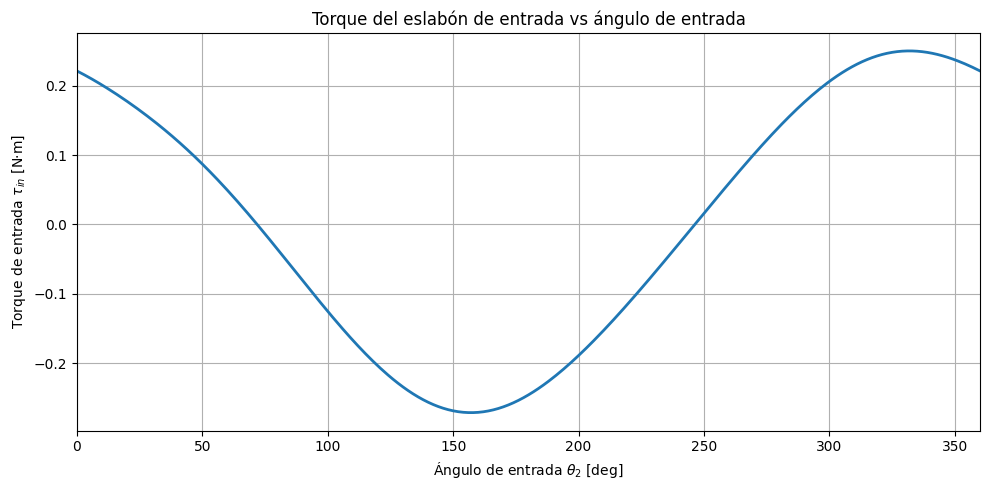

In [12]:
# =========================================
# GRÁFICA DEL TORQUE DE ENTRADA
# =========================================

plt.figure(figsize=(10, 5))
plt.plot(theta2_deg_list, tau_in_list, linewidth=2)
plt.xlabel(r'Ángulo de entrada $\theta_2$ [deg]')
plt.ylabel(r'Torque de entrada $\tau_{in}$ [N·m]')
plt.title('Torque requerido por el motor')
plt.grid(True)
plt.xlim(0, 360)
plt.tight_layout()
plt.show()


# =========================================
# GRÁFICA DE LA POTENCIA COMPLETA DEL MOTOR
# =========================================

plt.figure(figsize=(10, 5))
plt.plot(theta2_deg_list, P_in_list, linewidth=2)
plt.xlabel(r'Ángulo de entrada $\theta_2$ [deg]')
plt.ylabel('Potencia del motor [W]')
plt.title('Potencia completa requerida por el motor')
plt.grid(True)
plt.xlim(0, 360)
plt.tight_layout()
plt.show()


# =========================================
# POTENCIA ASOCIADA A LA FUERZA EXTERNA
# =========================================

plt.figure(figsize=(10, 5))
plt.plot(theta2_deg_list, PF_list, linewidth=2)
plt.xlabel(r'Ángulo de entrada $\theta_2$ [deg]')
plt.ylabel(r'Potencia $P_F$ [W]')
plt.title('Potencia asociada a la fuerza externa')
plt.grid(True)
plt.xlim(0, 360)
plt.tight_layout()
plt.show()


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. LEER ARCHIVO CSV
# =========================
csv_path = "RotaryMotor1 - Posición.csv"

df_exp = pd.read_csv(csv_path, skiprows=1)

# Renombrar columnas para trabajar cómodo
df_exp.columns = ["theta_deg_exp", "torque_Nmm_exp"]

# Conversión de unidades
df_exp["torque_Nm_exp"] = df_exp["torque_Nmm_exp"] * 1e-3

print(df_exp.head())
print(df_exp.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'RotaryMotor1 - Posición.csv'